In [1]:
# ── CELL 1: Imports and data loading ────────────────────────
#
# This is a standalone notebook. We import everything fresh
# and load master_dataset.csv directly. Nothing is inherited
# from the data collection or EDA notebooks.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']        = 130
plt.rcParams['font.size']         = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

os.makedirs('plots', exist_ok=True)
os.makedirs('results', exist_ok=True)

# ── Load and sort ─────────────────────────────────────────────
df_raw = pd.read_csv('/Users/tugrulcicekci/Desktop/tc_dsa210_project-main/Data Collection - EDA - Hypothesis/data/processed/master_dataset.csv')
df_raw['date'] = pd.to_datetime(df_raw['date'])

# CRITICAL: sort by ticker then date before ANY operation.
# Expanding window logic and lag computation both depend on
# strict chronological order within each ticker group.
df_raw = df_raw.sort_values(['ticker', 'date']).reset_index(drop=True)

TICKERS = ['COST', 'WMT', 'TGT', 'LOW']

print("Dataset loaded and sorted.")
print(f"Shape      : {df_raw.shape}")
print(f"Date range : {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"Tickers    : {df_raw['ticker'].unique().tolist()}")
print(f"\nColumns    : {df_raw.columns.tolist()}")
print(f"\nMissing values:\n{df_raw.isnull().sum()}")
print(f"\nTarget balance (overall):")
print(df_raw['target'].value_counts(normalize=True).round(3))
print(f"\nRows per ticker:\n{df_raw.groupby('ticker').size().to_string()}")

Dataset loaded and sorted.
Shape      : (284, 13)
Date range : 2020-02-29 → 2025-12-31
Tickers    : ['COST', 'LOW', 'TGT', 'WMT']

Columns    : ['date', 'ticker', 'monthly_return', 'target', 'vix_avg', 'rate_10y', 'net_margin', 'gross_margin', 'operating_margin', 'op_margin_change', 'de_ratio', 'current_ratio', 'sentiment_avg']

Missing values:
date                0
ticker              0
monthly_return      0
target              0
vix_avg             0
rate_10y            0
net_margin          0
gross_margin        0
operating_margin    0
op_margin_change    0
de_ratio            0
current_ratio       0
sentiment_avg       0
dtype: int64

Target balance (overall):
target
1    0.57
0    0.43
Name: proportion, dtype: float64

Rows per ticker:
ticker
COST    71
LOW     71
TGT     71
WMT     71


In [2]:
# ── CELL 2: Price-based feature engineering (BASE MODEL) ─────
#
# ALL features here are lagged by at least 1 month within each
# ticker. This means when we predict month T's direction, we
# only use data from month T-1 and earlier.
#
# .groupby('ticker') ensures we never mix COST's month with
# WMT's month — shifts stay within each stock's own timeline.

df = df_raw.copy()

# ── Momentum features ─────────────────────────────────────────
# Prior month return (shift 1 = use last month's return to predict this month)
df['mom_1m'] = df.groupby('ticker')['monthly_return'].shift(1)

# 3-month rolling mean of PAST returns (shift first, then rolling)
# shift(1) moves the series back one step, then rolling(3) averages
# the 3 months before the current prediction point
df['mom_3m'] = (df.groupby('ticker')['monthly_return']
                  .shift(1)
                  .rolling(3).mean()
                  .values)

# 6-month rolling mean of PAST returns
df['mom_6m'] = (df.groupby('ticker')['monthly_return']
                  .shift(1)
                  .rolling(6).mean()
                  .values)

# ── Volatility features ───────────────────────────────────────
# Rolling standard deviation of past returns — measures uncertainty
# High vol month followed by high vol next month (vol clustering)
df['vol_3m'] = (df.groupby('ticker')['monthly_return']
                  .shift(1)
                  .rolling(3).std()
                  .values)

df['vol_6m'] = (df.groupby('ticker')['monthly_return']
                  .shift(1)
                  .rolling(6).std()
                  .values)

# ── Trend / mean-reversion features ──────────────────────────
# Is last month's return above the 3-month average?
# 1 = momentum continuing, 0 = reverting
df['above_ma3'] = (df['mom_1m'] > df['mom_3m']).astype(float)

# Return acceleration: is short-term momentum stronger than medium-term?
# Positive = accelerating upward, Negative = decelerating
df['return_accel'] = df['mom_1m'] - df['mom_3m']

# ── Momentum sign consistency ─────────────────────────────────
# Were the last 3 months all positive? Streak signal.
# Computed as rolling sum of sign of past returns
df['pos_streak_3m'] = (
    df.groupby('ticker')['monthly_return']
    .transform(lambda x: x.shift(1).gt(0).rolling(3).sum())
)

print("Price-based features created:")
price_features = ['mom_1m', 'mom_3m', 'mom_6m',
                  'vol_3m', 'vol_6m', 'above_ma3',
                  'return_accel', 'pos_streak_3m']
print(price_features)
print(f"\nNaN introduced by rolling/shift:")
print(df[price_features].isnull().sum())
print(f"\nSample (COST, first 10 rows):")
print(df[df['ticker']=='COST'][['date','monthly_return','target']+price_features].head(10).to_string())

Price-based features created:
['mom_1m', 'mom_3m', 'mom_6m', 'vol_3m', 'vol_6m', 'above_ma3', 'return_accel', 'pos_streak_3m']

NaN introduced by rolling/shift:
mom_1m            4
mom_3m           12
mom_6m           24
vol_3m           12
vol_6m           24
above_ma3         0
return_accel     12
pos_streak_3m     8
dtype: int64

Sample (COST, first 10 rows):
        date  monthly_return  target    mom_1m    mom_3m    mom_6m    vol_3m    vol_6m  above_ma3  return_accel  pos_streak_3m
0 2020-02-29       -0.077858       0       NaN       NaN       NaN       NaN       NaN        0.0           NaN            NaN
1 2020-03-31        0.014192       1 -0.077858       NaN       NaN       NaN       NaN        0.0           NaN            NaN
2 2020-04-30        0.065101       1  0.014192       NaN       NaN       NaN       NaN        0.0           NaN            1.0
3 2020-05-31        0.018052       1  0.065101  0.000478       NaN  0.072460       NaN        1.0      0.064623            2.0


In [3]:
# ── CELL 3: Macro feature engineering (STAGE 1) ──────────────
#
# Macro features: VIX and 10Y rate from your existing dataset.
# The levels (vix_avg, rate_10y) are already in the dataset.
# Here we add CHANGES and ROLLING AVERAGES of these macro vars.
#
# LEAKAGE NOTE: macro features in your dataset represent the
# monthly average of that month. To use them as predictors for
# NEXT month's return, we must lag them by 1 month.
# e.g. January's VIX average → predicts February's direction.

# ── Lag the base macro levels by 1 month (per ticker group) ──
df['vix_lag1']  = df.groupby('ticker')['vix_avg'].shift(1)
df['rate_lag1'] = df.groupby('ticker')['rate_10y'].shift(1)

# ── VIX change: is fear rising or falling? ───────────────────
# vix_change = this month's VIX minus last month's VIX (both lagged)
df['vix_change'] = df.groupby('ticker')['vix_avg'].shift(1).diff()

# ── Rate change: is monetary policy tightening or loosening? ─
df['rate_change'] = df.groupby('ticker')['rate_10y'].shift(1).diff()

# ── 3-month rolling average VIX (lagged) ─────────────────────
# Smoothed fear baseline — is current VIX above/below recent norm?
df['vix_ma3'] = (df.groupby('ticker')['vix_avg']
                   .shift(1)
                   .rolling(3).mean()
                   .values)

# ── VIX regime: is current VIX above its 3m average? ─────────
# 1 = fear rising above recent baseline, 0 = fear below baseline
df['vix_elevated'] = (df['vix_lag1'] > df['vix_ma3']).astype(float)

# ── Rate regime: above or below 3%? (pre/post hiking cycle) ──
# 3% is a meaningful threshold — separates zero-rate era from
# the 2022-2025 high-rate environment
df['high_rate_regime'] = (df['rate_lag1'] > 3.0).astype(float)

# ── Macro stress interaction: VIX × rate ─────────────────────
# High VIX AND high rates simultaneously = double macro headwind
# Both lagged, so no leakage
df['macro_stress'] = df['vix_lag1'] * df['rate_lag1']

macro_features = ['vix_lag1', 'rate_lag1', 'vix_change', 'rate_change',
                  'vix_ma3', 'vix_elevated', 'high_rate_regime', 'macro_stress']

print("Macro features created:")
print(macro_features)
print(f"\nNaN counts:")
print(df[macro_features].isnull().sum())

Macro features created:
['vix_lag1', 'rate_lag1', 'vix_change', 'rate_change', 'vix_ma3', 'vix_elevated', 'high_rate_regime', 'macro_stress']

NaN counts:
vix_lag1             4
rate_lag1            4
vix_change           8
rate_change          8
vix_ma3             12
vix_elevated         0
high_rate_regime     0
macro_stress         4
dtype: int64


In [4]:
# ── CELL 4: Fundamental features (STAGE 2) ───────────────────
#
# Fundamental data in your dataset is already forward-filled
# from annual reports. However, it still represents information
# from the CURRENT month's row. We must lag everything by 1
# to predict NEXT month — same rule as macro features.
#
# We also compute CHANGES in fundamentals, because markets
# react more to whether margins are improving or deteriorating
# than to their absolute level.

FUND_COLS = ['net_margin', 'gross_margin', 'operating_margin',
             'op_margin_change', 'de_ratio', 'current_ratio']

# ── Lag all fundamental levels by 1 month ────────────────────
for col in FUND_COLS:
    df[f'{col}_lag1'] = df.groupby('ticker')[col].shift(1)

# ── Year-over-year change in margins ─────────────────────────
# shift(12) goes back 12 months within the same ticker
# This captures whether this year's margins are better/worse
# than the same period last year
df['net_margin_yoy']  = (df.groupby('ticker')['net_margin']
                           .shift(1)
                           .diff(12))

df['op_margin_yoy']   = (df.groupby('ticker')['operating_margin']
                           .shift(1)
                           .diff(12))

df['gross_margin_yoy'] = (df.groupby('ticker')['gross_margin']
                            .shift(1)
                            .diff(12))

# ── Margin improvement flag ───────────────────────────────────
# 1 if operating margin improved vs last year, 0 if declined
df['margin_improving'] = (df['op_margin_yoy'] > 0).astype(float)

# ── Leverage trend ────────────────────────────────────────────
# Is debt/equity rising? Rising leverage = increasing risk
df['de_ratio_change'] = df.groupby('ticker')['de_ratio'].shift(1).diff(4)

# ── COMBINATION FEATURES ─────────────────────────────────────
# These are financially motivated combinations that capture
# concepts no single feature represents alone.

# 1. Margin efficiency: how much of gross profit survives to operating profit
#    High = lean operations (LOW), Low = high SG&A burden (TGT)
#    Clipped to avoid division by near-zero
gm = df['gross_margin_lag1'].clip(lower=0.01)
df['margin_efficiency'] = (df['operating_margin_lag1'] / gm).clip(-5, 5)

# 2. Quality-adjusted leverage: profitable companies can handle more debt
#    High net_margin + low de_ratio = high quality = positive signal
#    We clip de_ratio because LOW is negative (buybacks not distress)
de_clipped = df['de_ratio_lag1'].clip(-1, 3)
df['quality_leverage'] = df['net_margin_lag1'] / (1 + de_clipped.abs())

# 3. Macro-margin interaction: does margin improvement matter more when
#    macro environment is benign (low VIX)?
#    Positive = margin improving AND fear is low = strong buy signal
df['margin_macro_score'] = df['op_margin_yoy'] * (1 / df['vix_lag1'].clip(lower=1))

# 4. Momentum-volatility ratio (Sharpe-like signal)
#    Is recent return high relative to recent volatility?
#    Positive = good risk-adjusted momentum
df['mom_vol_ratio'] = (df['mom_3m'] / df['vol_3m'].clip(lower=0.001)).clip(-10, 10)

# 5. Stress-momentum interaction: momentum in high-VIX regime
#    When market is fearful, positive momentum is extra meaningful
df['stress_momentum'] = df['mom_1m'] * df['vix_lag1']

fund_features_lag = [f'{c}_lag1' for c in FUND_COLS]
fund_features_yoy = ['net_margin_yoy', 'op_margin_yoy', 'gross_margin_yoy',
                     'margin_improving', 'de_ratio_change']
combo_features    = ['margin_efficiency', 'quality_leverage',
                     'margin_macro_score', 'mom_vol_ratio', 'stress_momentum']

print("Fundamental (lagged) features:", fund_features_lag)
print("\nYoY change features:", fund_features_yoy)
print("\nCombination features:", combo_features)
print(f"\nNaN counts (fundamentals):")
print(df[fund_features_lag + fund_features_yoy].isnull().sum())
print(f"\nNaN counts (combinations):")
print(df[combo_features].isnull().sum())

Fundamental (lagged) features: ['net_margin_lag1', 'gross_margin_lag1', 'operating_margin_lag1', 'op_margin_change_lag1', 'de_ratio_lag1', 'current_ratio_lag1']

YoY change features: ['net_margin_yoy', 'op_margin_yoy', 'gross_margin_yoy', 'margin_improving', 'de_ratio_change']

Combination features: ['margin_efficiency', 'quality_leverage', 'margin_macro_score', 'mom_vol_ratio', 'stress_momentum']

NaN counts (fundamentals):
net_margin_lag1           4
gross_margin_lag1         4
operating_margin_lag1     4
op_margin_change_lag1     4
de_ratio_lag1             4
current_ratio_lag1        4
net_margin_yoy           19
op_margin_yoy            19
gross_margin_yoy         19
margin_improving          0
de_ratio_change          11
dtype: int64

NaN counts (combinations):
margin_efficiency      4
quality_leverage       4
margin_macro_score    19
mom_vol_ratio         12
stress_momentum        4
dtype: int64


In [5]:
# ── CELL 5: Build final ML-ready dataset ─────────────────────
#
# Steps:
# 1. Add ticker dummy variables (one-hot encoding)
# 2. Define the three feature sets (Base, Stage1, Stage2)
# 3. Drop rows where rolling features are NaN (warmup period)
# 4. Final leakage audit before saving

# ── Ticker dummies ────────────────────────────────────────────
# The model needs to know which stock it's predicting.
# We encode COST/WMT/TGT/LOW as binary columns (0 or 1).
# drop_first=True drops one column to avoid perfect multicollinearity.
ticker_dummies = pd.get_dummies(df['ticker'], prefix='ticker', drop_first=True)
df = pd.concat([df, ticker_dummies], axis=1)
ticker_cols = ticker_dummies.columns.tolist()
print(f"Ticker dummies added: {ticker_cols}")

# ── Define feature sets ───────────────────────────────────────
# BASE MODEL: price/momentum only — always available
BASE_FEATURES = [
    'mom_1m', 'mom_3m', 'mom_6m',
    'vol_3m', 'vol_6m',
    'above_ma3', 'return_accel', 'pos_streak_3m'
] + ticker_cols

# STAGE 1: Base + macro
STAGE1_FEATURES = BASE_FEATURES + [
    'vix_lag1', 'rate_lag1',
    'vix_change', 'rate_change',
    'vix_ma3', 'vix_elevated',
    'high_rate_regime', 'macro_stress'
]

# STAGE 2: Stage 1 + fundamentals + combinations
# Note: current_ratio excluded (near-zero variation in 3 of 4 stocks)
# Note: op_margin_change_lag1 kept (has more variation than other fund cols)
STAGE2_FEATURES = STAGE1_FEATURES + [
    'net_margin_lag1', 'gross_margin_lag1', 'operating_margin_lag1',
    'op_margin_change_lag1', 'de_ratio_lag1',
    'net_margin_yoy', 'op_margin_yoy', 'gross_margin_yoy',
    'margin_improving', 'de_ratio_change',
    'margin_efficiency', 'quality_leverage',
    'margin_macro_score', 'mom_vol_ratio', 'stress_momentum'
]

TARGET = 'target'

print(f"\nFeature set sizes:")
print(f"  Base    : {len(BASE_FEATURES)} features")
print(f"  Stage 1 : {len(STAGE1_FEATURES)} features")
print(f"  Stage 2 : {len(STAGE2_FEATURES)} features")

# ── Drop NaN rows ─────────────────────────────────────────────
# Rolling(6) needs 6 rows of history. shift(12) for YoY needs 12+1.
# The first ~13 months of each ticker will have NaN in some features.
# We drop these rows — they cannot be used for training or testing.
all_features_used = list(set(STAGE2_FEATURES))
df_ml = df.dropna(subset=all_features_used + [TARGET]).copy()
df_ml = df_ml.sort_values(['ticker', 'date']).reset_index(drop=True)

print(f"\nRows before dropping NaN : {len(df)}")
print(f"Rows after dropping NaN  : {len(df_ml)}")
print(f"Rows lost (warmup period): {len(df) - len(df_ml)}")
print(f"\nDate range after cleaning: {df_ml['date'].min().date()} → {df_ml['date'].max().date()}")
print(f"Rows per ticker:\n{df_ml.groupby('ticker').size().to_string()}")
print(f"\nTarget balance after cleaning:")
print(df_ml[TARGET].value_counts(normalize=True).round(3))

# ── LEAKAGE AUDIT ─────────────────────────────────────────────
# Double-check: no feature uses current month's data directly.
# monthly_return and target should NOT be in any feature set.
leakage_cols = ['monthly_return', 'target', 'vix_avg', 'rate_10y',
                'net_margin', 'gross_margin', 'operating_margin',
                'op_margin_change', 'de_ratio', 'current_ratio',
                'sentiment_avg']

print("\n=== LEAKAGE AUDIT ===")
print("Checking that raw (unlagged) columns are NOT in feature sets...")
for stage, features in [('Base', BASE_FEATURES),
                         ('Stage1', STAGE1_FEATURES),
                         ('Stage2', STAGE2_FEATURES)]:
    leaked = [c for c in features if c in leakage_cols]
    if leaked:
        print(f"  ⚠️  {stage} LEAKAGE DETECTED: {leaked}")
    else:
        print(f"  ✓  {stage}: No leakage detected")

df_ml.to_csv('/Users/tugrulcicekci/Desktop/tc_dsa210_project-main/Data Collection - EDA - Hypothesis/data/processed/ml_ready_dataset.csv', index=False)

print(f"\nML-ready dataset saved to data/processed/ml_ready_dataset.csv")

Ticker dummies added: ['ticker_LOW', 'ticker_TGT', 'ticker_WMT']

Feature set sizes:
  Base    : 11 features
  Stage 1 : 19 features
  Stage 2 : 34 features

Rows before dropping NaN : 284
Rows after dropping NaN  : 250
Rows lost (warmup period): 34

Date range after cleaning: 2020-08-31 → 2025-12-31
Rows per ticker:
ticker
COST    58
LOW     64
TGT     64
WMT     64

Target balance after cleaning:
target
1    0.568
0    0.432
Name: proportion, dtype: float64

=== LEAKAGE AUDIT ===
Checking that raw (unlagged) columns are NOT in feature sets...
  ✓  Base: No leakage detected
  ✓  Stage1: No leakage detected
  ✓  Stage2: No leakage detected

ML-ready dataset saved to data/processed/ml_ready_dataset.csv


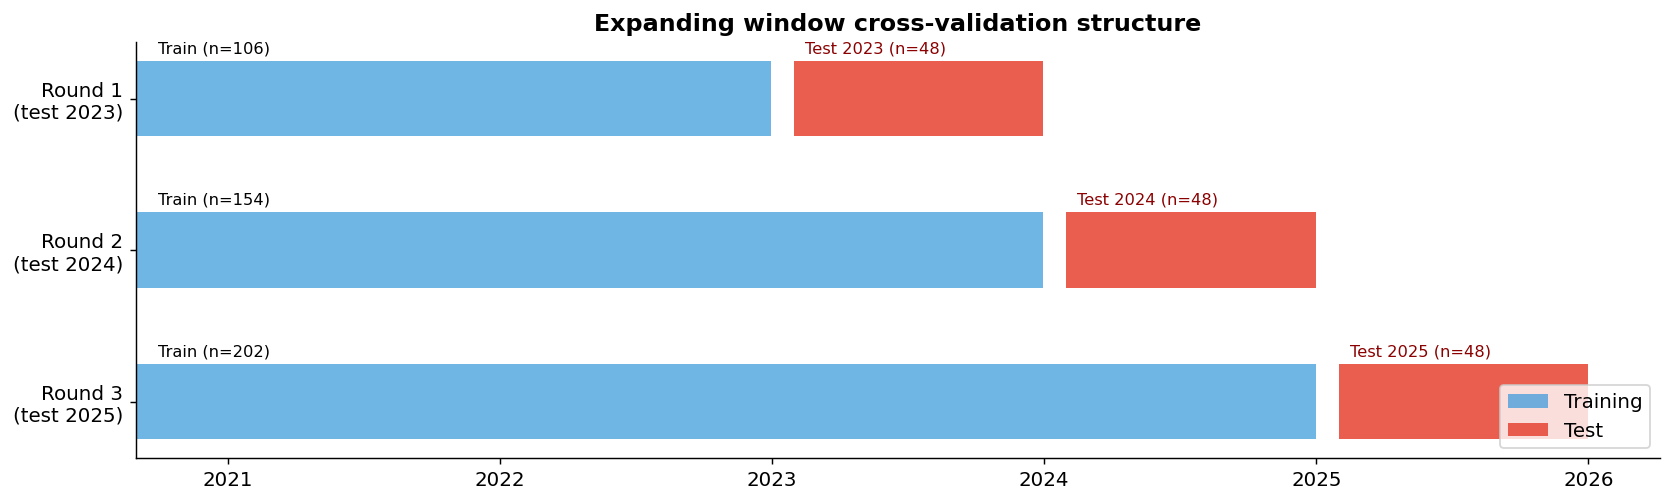

Split summary:

  Round: test year = 2023
    Train: 2020-08-31 → 2022-12-31 (n=106, up%=56.6%)
    Test : 2023-01-31 → 2023-12-31 (n=48, up%=60.4%)

  Round: test year = 2024
    Train: 2020-08-31 → 2023-12-31 (n=154, up%=57.8%)
    Test : 2024-01-31 → 2024-12-31 (n=48, up%=58.3%)

  Round: test year = 2025
    Train: 2020-08-31 → 2024-12-31 (n=202, up%=57.9%)
    Test : 2025-01-31 → 2025-12-31 (n=48, up%=52.1%)


In [6]:
# ── CELL 6: Expanding window split generator ─────────────────
#
# EXPANDING WINDOW means each round keeps all prior training data
# and adds the most recent completed year. This simulates how a
# real practitioner would retrain a model annually:
#   Round 1: train 2020-2022 → test 2023
#   Round 2: train 2020-2023 → test 2024
#   Round 3: train 2020-2024 → test 2025
#
# Why NOT random split for time series:
# If we randomly split, the model might train on March 2024 and
# test on March 2023 — it has "seen the future" during training.
# Expanding window prevents this completely.

def expanding_window_splits(df, test_years, date_col='date'):
    """
    Generates (train_idx, test_idx) pairs for expanding window CV.

    Parameters:
    -----------
    df        : DataFrame sorted by date
    test_years: list of years to use as test periods, e.g. [2023, 2024, 2025]
    date_col  : name of the date column

    Yields:
    -------
    (train_mask, test_mask, test_year) tuples
    """
    for test_year in test_years:
        # Training: all data STRICTLY BEFORE the test year
        train_mask = df[date_col].dt.year < test_year
        # Test: exactly the test year
        test_mask  = df[date_col].dt.year == test_year

        n_train = train_mask.sum()
        n_test  = test_mask.sum()

        if n_train < 10 or n_test < 1:
            print(f"  Skipping {test_year}: insufficient data "
                  f"(train={n_train}, test={n_test})")
            continue

        yield train_mask, test_mask, test_year


# ── Visualise the splits ──────────────────────────────────────
TEST_YEARS = [2023, 2024, 2025]

fig, ax = plt.subplots(figsize=(13, 4))
colors = {'train': '#3498db', 'test': '#e74c3c'}
y_positions = {2023: 3, 2024: 2, 2025: 1}

for train_mask, test_mask, test_year in expanding_window_splits(df_ml, TEST_YEARS):
    y = y_positions[test_year]
    train_dates = df_ml.loc[train_mask, 'date']
    test_dates  = df_ml.loc[test_mask,  'date']

    ax.barh(y, (train_dates.max() - train_dates.min()).days,
            left=mdates.date2num(train_dates.min()),
            height=0.5, color=colors['train'], alpha=0.7,
            label='Training' if test_year == 2023 else '')
    ax.barh(y, (test_dates.max() - test_dates.min()).days,
            left=mdates.date2num(test_dates.min()),
            height=0.5, color=colors['test'], alpha=0.9,
            label='Test' if test_year == 2023 else '')

    ax.text(mdates.date2num(train_dates.min()) + 30, y + 0.3,
            f'Train (n={len(train_dates)})', fontsize=9)
    ax.text(mdates.date2num(test_dates.min()) + 15, y + 0.3,
            f'Test {test_year} (n={len(test_dates)})', fontsize=9, color='darkred')

ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['Round 3\n(test 2025)', 'Round 2\n(test 2024)', 'Round 1\n(test 2023)'])
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Expanding window cross-validation structure', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plots/ml_expanding_window.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print split summary ───────────────────────────────────────
print("Split summary:")
for train_mask, test_mask, test_year in expanding_window_splits(df_ml, TEST_YEARS):
    tr = df_ml[train_mask]
    te = df_ml[test_mask]
    print(f"\n  Round: test year = {test_year}")
    print(f"    Train: {tr['date'].min().date()} → {tr['date'].max().date()} "
          f"(n={len(tr)}, up%={tr[TARGET].mean():.1%})")
    print(f"    Test : {te['date'].min().date()} → {te['date'].max().date()} "
          f"(n={len(te)}, up%={te[TARGET].mean():.1%})")

In [7]:
# ── CELL 7: Baseline + evaluation infrastructure ─────────────
#
# The majority-class baseline always predicts "1" (up month)
# because ~57% of months are up. It achieves ~57% accuracy
# by doing absolutely nothing intelligent.
#
# Any real model must beat this. If your Random Forest gets 57%
# too — it learned nothing beyond the base rate.
#
# We define evaluate_model() here once and reuse it for every
# model/stage combination so results are perfectly comparable.

def majority_class_baseline(y_test):
    """Returns accuracy of always predicting the majority class."""
    majority = int(pd.Series(y_test).mode()[0])
    preds    = np.full(len(y_test), majority)
    return accuracy_score(y_test, preds), preds, majority


def evaluate_model(y_true, y_pred, returns_true, stage_name,
                   test_year, verbose=True):
    """
    Computes and returns all evaluation metrics for one model/round.

    Metrics:
    --------
    accuracy         : % of correct direction predictions
    return_weighted  : sum of returns × (1 if correct, -1 if wrong)
                       measures economic value of predictions
    avg_return_long  : average return when model predicted "up"
    avg_return_all   : average return of all predicted months
    strategy_return  : cumulative return of going long when model says up
    """
    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    returns = np.array(returns_true)

    acc = accuracy_score(y_true, y_pred)

    # Return-weighted score: correct prediction → +|return|, wrong → -|return|
    correct      = (y_true == y_pred).astype(int) * 2 - 1  # +1 correct, -1 wrong
    ret_weighted = np.sum(correct * np.abs(returns))

    # Strategy: go long only when model predicts up (target=1)
    long_mask        = (y_pred == 1)
    strategy_returns = returns[long_mask]
    avg_long_return  = strategy_returns.mean() if long_mask.sum() > 0 else 0.0
    cumulative_ret   = (1 + strategy_returns).prod() - 1 if long_mask.sum() > 0 else 0.0

    # Buy-and-hold benchmark
    bah_return = (1 + returns).prod() - 1

    result = {
        'stage':           stage_name,
        'test_year':       test_year,
        'n_test':          len(y_true),
        'accuracy':        round(acc, 4),
        'ret_weighted':    round(ret_weighted, 4),
        'avg_long_return': round(avg_long_return, 4),
        'strategy_cum_ret':round(cumulative_ret, 4),
        'bah_cum_ret':     round(bah_return, 4),
        'n_long_signals':  int(long_mask.sum()),
    }

    if verbose:
        print(f"\n  {'─'*45}")
        print(f"  Stage: {stage_name} | Test year: {test_year}")
        print(f"  {'─'*45}")
        print(f"  Accuracy         : {acc:.1%}")
        print(f"  Return-weighted  : {ret_weighted:+.4f}")
        print(f"  Avg return (long): {avg_long_return:+.3%}")
        print(f"  Strategy cum ret : {cumulative_ret:+.2%}")
        print(f"  Buy-hold cum ret : {bah_return:+.2%}")
        print(f"  Long signals     : {long_mask.sum()} of {len(y_pred)} months")

    return result


# ── Compute baseline for each test year ──────────────────────
print("=== MAJORITY CLASS BASELINE ===")
baseline_results = []
for train_mask, test_mask, test_year in expanding_window_splits(df_ml, TEST_YEARS):
    y_test   = df_ml.loc[test_mask, TARGET]
    ret_test = df_ml.loc[test_mask, 'monthly_return']
    acc, preds, majority = majority_class_baseline(y_test)
    res = evaluate_model(y_test, preds, ret_test,
                         'Baseline', test_year)
    baseline_results.append(res)

baseline_df = pd.DataFrame(baseline_results)
print("\nBaseline summary:")
print(baseline_df[['test_year','accuracy','strategy_cum_ret','bah_cum_ret']].to_string(index=False))
print(f"\nMean baseline accuracy: {baseline_df['accuracy'].mean():.1%}")

=== MAJORITY CLASS BASELINE ===

  ─────────────────────────────────────────────
  Stage: Baseline | Test year: 2023
  ─────────────────────────────────────────────
  Accuracy         : 60.4%
  Return-weighted  : +0.7560
  Avg return (long): +1.575%
  Strategy cum ret : +89.21%
  Buy-hold cum ret : +89.21%
  Long signals     : 48 of 48 months

  ─────────────────────────────────────────────
  Stage: Baseline | Test year: 2024
  ─────────────────────────────────────────────
  Accuracy         : 58.3%
  Return-weighted  : +1.1014
  Avg return (long): +2.295%
  Strategy cum ret : +168.31%
  Buy-hold cum ret : +168.31%
  Long signals     : 48 of 48 months

  ─────────────────────────────────────────────
  Stage: Baseline | Test year: 2025
  ─────────────────────────────────────────────
  Accuracy         : 52.1%
  Return-weighted  : -0.0216
  Avg return (long): -0.045%
  Strategy cum ret : -10.17%
  Buy-hold cum ret : -10.17%
  Long signals     : 48 of 48 months

Baseline summary:
 test_ye

In [9]:
# ── CELL 8: Run expanding window across all three stages ──────
#
# For each test year (2023, 2024, 2025):
#   - Train Base model on data before test year → predict test year
#   - Train Stage1 model on same data → predict test year
#   - Train Stage2 model on same data → predict test year
#
# RandomForest hyperparameters chosen conservatively:
#   n_estimators=200  : enough trees for stable importance scores
#   max_depth=4       : shallow trees prevent overfitting on small N
#   min_samples_leaf=5: each leaf needs at least 5 samples
#   class_weight='balanced': compensates for 57/43 imbalance
#   random_state=42   : reproducibility
"""
RF_PARAMS = dict(
    n_estimators   = 200,
    max_depth      = 4,
    min_samples_leaf = 5,
    class_weight   = 'balanced',
    random_state   = 42,
    n_jobs         = -1
)
"""
DEFAULT_PARAMS = dict(
    n_estimators    = 200,
    max_depth       = 4,
    min_samples_leaf= 5,
    class_weight    = 'balanced',
    random_state    = 42,
    n_jobs          = -1
)
STAGE_FEATURES = {
    'Base'  : BASE_FEATURES,
    'Stage1': STAGE1_FEATURES,
    'Stage2': STAGE2_FEATURES,
}

all_results      = []
all_predictions  = []   # store raw predictions for portfolio analysis
feature_importances = {stage: [] for stage in STAGE_FEATURES}

print("=" * 55)
print("  EXPANDING WINDOW TRAINING — ALL STAGES")
print("=" * 55)

for train_mask, test_mask, test_year in expanding_window_splits(df_ml, TEST_YEARS):

    X_train_full = df_ml[train_mask]
    X_test_full  = df_ml[test_mask]
    y_train      = df_ml.loc[train_mask, TARGET]
    y_test       = df_ml.loc[test_mask,  TARGET]
    ret_test     = df_ml.loc[test_mask,  'monthly_return']

    print(f"\n{'='*55}")
    print(f"  TEST YEAR: {test_year}  |  "
          f"Train n={len(y_train)}  Test n={len(y_test)}")
    print(f"{'='*55}")

    # Baseline for this round
    acc_bl, preds_bl, _ = majority_class_baseline(y_test)
    res_bl = evaluate_model(y_test, preds_bl, ret_test, 'Baseline', test_year)
    all_results.append(res_bl)

    for stage_name, features in STAGE_FEATURES.items():

        # Filter to features that exist in the dataframe
        feats = [f for f in features if f in df_ml.columns]

        X_train = X_train_full[feats]
        X_test  = X_test_full[feats]

        # Train Random Forest
        model = RandomForestClassifier(**DEFAULT_PARAMS)
        model.fit(X_train, y_train)

        # Predict
        y_pred      = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]  # prob of up

        # Evaluate
        res = evaluate_model(y_test, y_pred, ret_test, stage_name, test_year)
        all_results.append(res)

        # Store predictions with metadata for portfolio analysis
        pred_df = X_test_full[['date', 'ticker']].copy()
        pred_df['y_true']      = y_test.values
        pred_df['y_pred']      = y_pred
        pred_df['y_prob']      = y_pred_proba
        pred_df['monthly_return'] = ret_test.values
        pred_df['stage']       = stage_name
        pred_df['test_year']   = test_year
        all_predictions.append(pred_df)

        # Store feature importances
        imp_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_,
    'test_year': [test_year] * len(model.feature_importances_)
}).sort_values('importance', ascending=False)
        feature_importances[stage_name].append(imp_df)

# ── Compile all results ───────────────────────────────────────
results_df  = pd.DataFrame(all_results)
preds_df    = pd.concat(all_predictions, ignore_index=True)

results_df.to_csv('results/model_results.csv', index=False)
preds_df.to_csv('results/all_predictions.csv', index=False)

print("\n\n=== RESULTS SUMMARY ===")
pivot = results_df.pivot_table(
    index='stage', columns='test_year',
    values='accuracy', aggfunc='first'
).round(3)
print("\nAccuracy by stage and test year:")
print(pivot.to_string())

print("\nMean accuracy across all test years:")
print(results_df.groupby('stage')['accuracy'].mean().round(3).to_string())

  EXPANDING WINDOW TRAINING — ALL STAGES

  TEST YEAR: 2023  |  Train n=106  Test n=48

  ─────────────────────────────────────────────
  Stage: Baseline | Test year: 2023
  ─────────────────────────────────────────────
  Accuracy         : 60.4%
  Return-weighted  : +0.7560
  Avg return (long): +1.575%
  Strategy cum ret : +89.21%
  Buy-hold cum ret : +89.21%
  Long signals     : 48 of 48 months

  ─────────────────────────────────────────────
  Stage: Base | Test year: 2023
  ─────────────────────────────────────────────
  Accuracy         : 64.6%
  Return-weighted  : +0.4603
  Avg return (long): +1.789%
  Strategy cum ret : +68.04%
  Buy-hold cum ret : +89.21%
  Long signals     : 34 of 48 months

  ─────────────────────────────────────────────
  Stage: Stage1 | Test year: 2023
  ─────────────────────────────────────────────
  Accuracy         : 56.2%
  Return-weighted  : +0.0922
  Avg return (long): +1.631%
  Strategy cum ret : +41.89%
  Buy-hold cum ret : +89.21%
  Long signals   

In [10]:
# ── CELL 8.5: Hyperparameter tuning with TimeSeriesSplit ──────
#
# WHAT: Find the best Random Forest hyperparameters for each
#       feature stage using time-respecting cross-validation.
#
# WHY TimeSeriesSplit and not GridSearchCV with shuffle:
#   Standard CV randomly mixes past and future — leakage.
#   TimeSeriesSplit always trains on past, validates on future.
#   This mirrors the expanding window we use for final evaluation.
#
# APPROACH:
#   1. Use ALL training data (before 2023) for tuning
#   2. TimeSeriesSplit with 3 folds on this training data
#   3. Score each param combination by mean accuracy across folds
#   4. Use best params in the expanding window training loop
#
# NOTE ON DATASET SIZE:
#   ~116 training rows is small. We use conservative param ranges
#   to avoid overfitting. Deep trees and many features overfit
#   badly on small tabular datasets.

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import time

# ── Parameter grid ────────────────────────────────────────────
# Kept deliberately narrow for small dataset:
#   max_depth    : 3-5 only (deep trees overfit ~116 rows badly)
#   min_samples_leaf: 5-15 (forces generalisable splits)
#   max_features : sqrt or 0.5 (reduces tree correlation)
#   n_estimators : 100-300 (more trees = stable importances)

PARAM_GRID = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [3, 4, 5],
    'min_samples_leaf':[5, 8, 12],
    'max_features':    ['sqrt', 0.5],
}

# ── TimeSeriesSplit config ────────────────────────────────────
# 3 folds on training data (before 2023).
# Each fold adds ~20 rows to training, validates on next ~20.
# n_splits=3 is appropriate for ~116 rows — more splits would
# make each validation set too small to be meaningful.
TS_CV = TimeSeriesSplit(n_splits=3)

# ── Use data before 2023 for tuning ──────────────────────────
# This is the same training data used in Round 1 of expanding window.
# Tuning on this window is conservative and prevents peeking at
# the 2023/2024/2025 test years.
tune_mask = df_ml['date'].dt.year < 2023

best_params_per_stage = {}

print("=" * 60)
print("  HYPERPARAMETER TUNING")
print(f"  Tuning data: {df_ml[tune_mask]['date'].min().date()} → "
      f"{df_ml[tune_mask]['date'].max().date()}")
print(f"  Tuning rows: {tune_mask.sum()}")
print(f"  CV strategy: TimeSeriesSplit(n_splits=3)")
print(f"  Scoring    : accuracy")
print("=" * 60)

for stage_name, features in STAGE_FEATURES.items():

    feats = [f for f in features if f in df_ml.columns]
    X_tune = df_ml[tune_mask][feats]
    y_tune = df_ml[tune_mask][TARGET]

    print(f"\n── Tuning {stage_name} ({len(feats)} features) ──")
    t0 = time.time()

    # GridSearchCV with TimeSeriesSplit
    # refit=True: after finding best params, refit on all tuning data
    # n_jobs=-1: use all CPU cores
    gs = GridSearchCV(
        estimator  = RandomForestClassifier(
                         class_weight='balanced',
                         random_state=42,
                         n_jobs=-1),
        param_grid = PARAM_GRID,
        cv         = TS_CV,
        scoring    = 'accuracy',
        refit      = True,
        n_jobs     = -1,
        verbose    = 0
    )
    gs.fit(X_tune, y_tune)

    best_params_per_stage[stage_name] = gs.best_params_
    elapsed = time.time() - t0

    print(f"  Best params  : {gs.best_params_}")
    print(f"  Best CV score: {gs.best_score_:.4f}")
    print(f"  Time elapsed : {elapsed:.1f}s")

    # Show top 5 param combinations
    cv_results = pd.DataFrame(gs.cv_results_)
    top5 = (cv_results[['params','mean_test_score','std_test_score']]
            .sort_values('mean_test_score', ascending=False)
            .head(5))
    print(f"\n  Top 5 parameter combinations:")
    for _, row in top5.iterrows():
        print(f"    {row['params']}  →  "
              f"mean={row['mean_test_score']:.4f}  "
              f"std={row['std_test_score']:.4f}")

print("\n\n=== BEST PARAMETERS SUMMARY ===")
for stage, params in best_params_per_stage.items():
    print(f"\n{stage}:")
    for k, v in params.items():
        print(f"  {k:<20}: {v}")

  HYPERPARAMETER TUNING
  Tuning data: 2020-08-31 → 2022-12-31
  Tuning rows: 106
  CV strategy: TimeSeriesSplit(n_splits=3)
  Scoring    : accuracy

── Tuning Base (11 features) ──
  Best params  : {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 12, 'n_estimators': 300}
  Best CV score: 0.5513
  Time elapsed : 10.2s

  Top 5 parameter combinations:
    {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 12, 'n_estimators': 300}  →  mean=0.5513  std=0.0725
    {'max_depth': 4, 'max_features': 0.5, 'min_samples_leaf': 8, 'n_estimators': 100}  →  mean=0.5513  std=0.0480
    {'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 8, 'n_estimators': 100}  →  mean=0.5513  std=0.0480
    {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 12, 'n_estimators': 300}  →  mean=0.5513  std=0.0725
    {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 12, 'n_estimators': 300}  →  mean=0.5513  std=0.0725

── Tuning Stage1 (19 features) ──
  Best params  : {

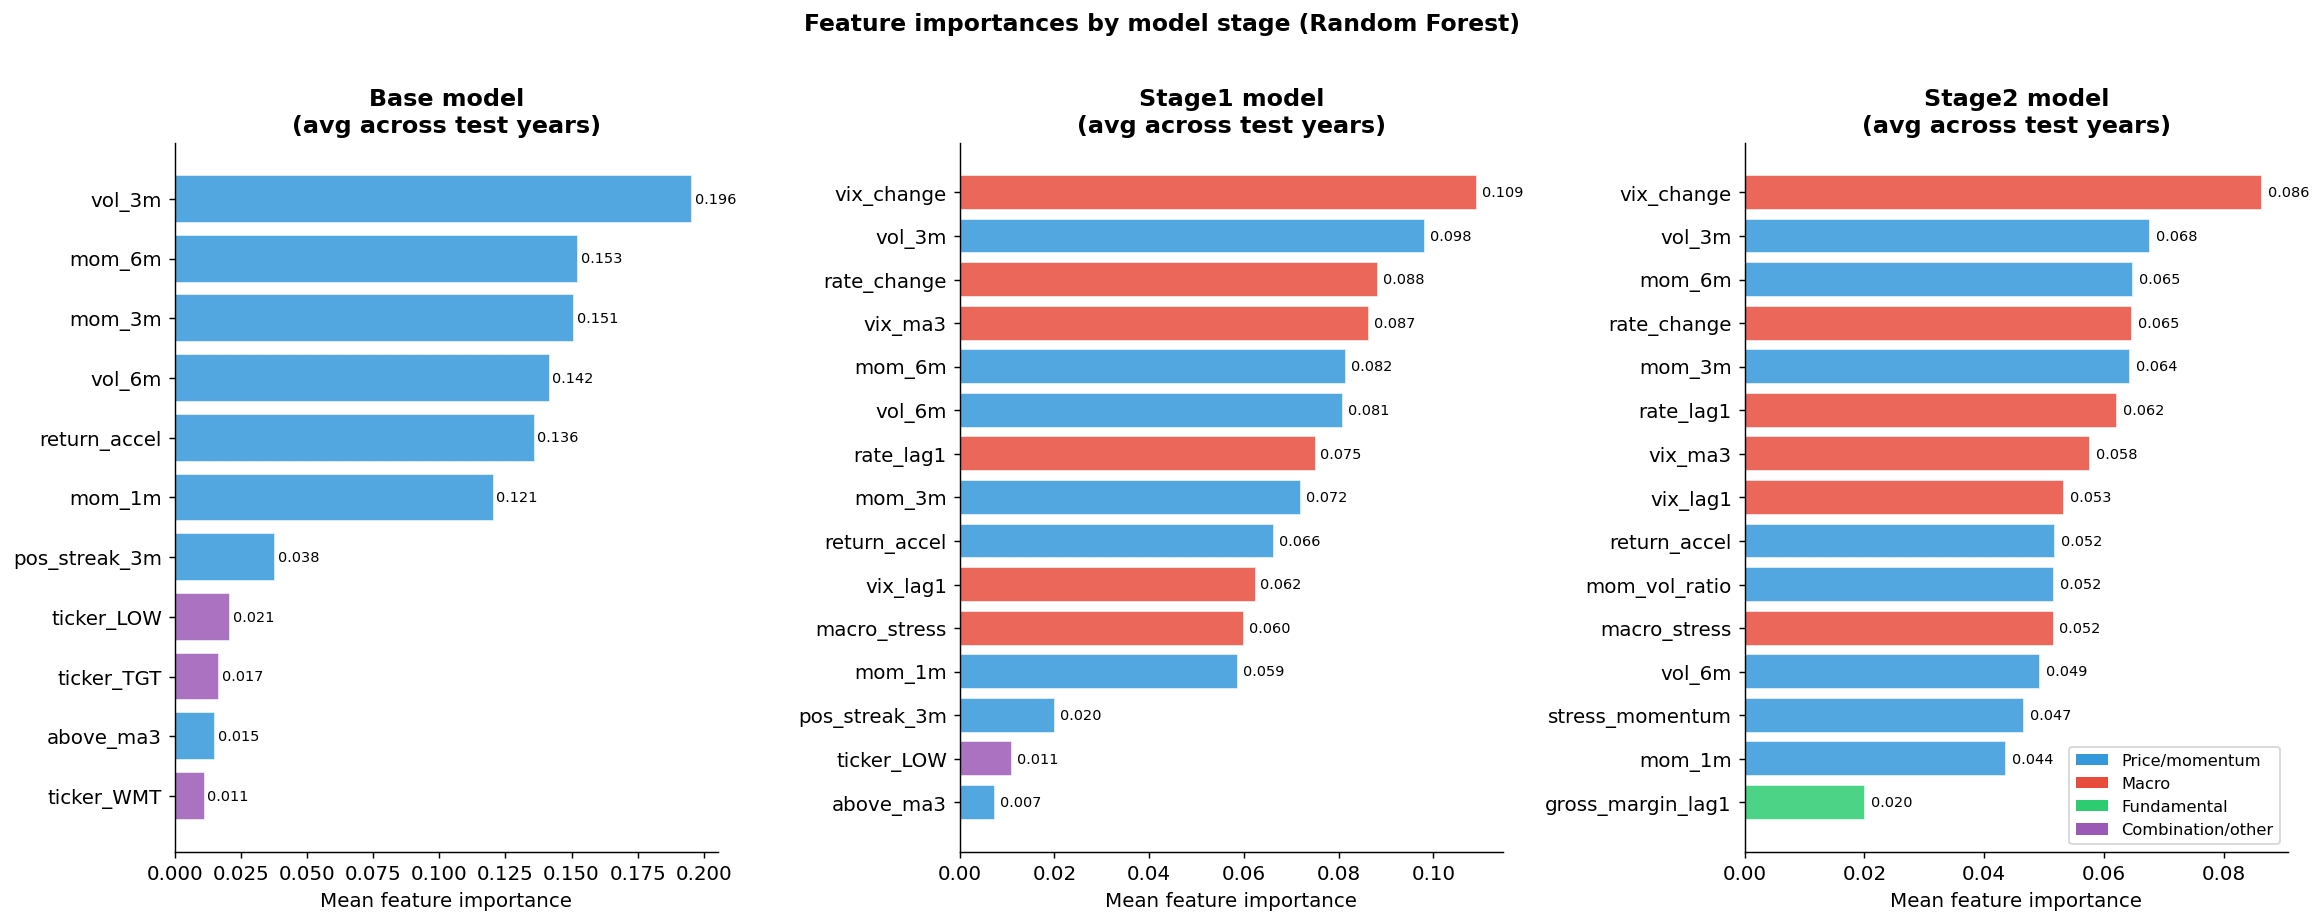

Top 10 features per stage (averaged across test years):

Base:
  vol_3m                        : 0.1956
  mom_6m                        : 0.1526
  mom_3m                        : 0.1511
  vol_6m                        : 0.1418
  return_accel                  : 0.1360
  mom_1m                        : 0.1206
  pos_streak_3m                 : 0.0379
  ticker_LOW                    : 0.0210
  ticker_TGT                    : 0.0167
  above_ma3                     : 0.0153

Stage1:
  vix_change                    : 0.1093
  vol_3m                        : 0.0982
  rate_change                   : 0.0883
  vix_ma3                       : 0.0865
  mom_6m                        : 0.0815
  vol_6m                        : 0.0809
  rate_lag1                     : 0.0752
  mom_3m                        : 0.0720
  return_accel                  : 0.0664
  vix_lag1                      : 0.0625

Stage2:
  vix_change                    : 0.0864
  vol_3m                        : 0.0678
  mom_6m         

In [11]:
# ── CELL 9: Feature importance analysis ───────────────────────
#
# Random Forest computes importance as: how much does each feature
# reduce impurity (Gini) across all trees and all splits?
# Higher = more important for predictions.
#
# We compare importances across stages to understand:
# 1. What drives the Base model (should be momentum + VIX)
# 2. What does Stage1 add over Base
# 3. Do fundamentals contribute in Stage2?

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (stage_name, imp_list) in zip(axes, feature_importances.items()):

    # Average importance across all test years
    all_imp = pd.concat(imp_list)
    avg_imp = (all_imp.groupby('feature')['importance']
                      .mean()
                      .sort_values(ascending=True)
                      .tail(15))  # top 15 features

    colors_bar = ['#e74c3c' if 'macro' in f or 'vix' in f or 'rate' in f
                  else '#3498db' if 'mom' in f or 'vol' in f or 'above' in f
                  or 'accel' in f or 'streak' in f
                  else '#2ecc71' if 'margin' in f or 'net_' in f
                  or 'gross' in f or 'op_' in f or 'de_' in f
                  else '#9b59b6'
                  for f in avg_imp.index]

    ax.barh(avg_imp.index, avg_imp.values,
            color=colors_bar, alpha=0.85, edgecolor='white')
    ax.set_title(f'{stage_name} model\n(avg across test years)',
                 fontweight='bold')
    ax.set_xlabel('Mean feature importance')

    # Add value labels
    for i, (feat, val) in enumerate(avg_imp.items()):
        ax.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Price/momentum'),
    Patch(facecolor='#e74c3c', label='Macro'),
    Patch(facecolor='#2ecc71', label='Fundamental'),
    Patch(facecolor='#9b59b6', label='Combination/other'),
]
axes[2].legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.suptitle('Feature importances by model stage (Random Forest)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/ml_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print top 10 per stage ────────────────────────────────────
print("Top 10 features per stage (averaged across test years):")
for stage_name, imp_list in feature_importances.items():
    all_imp = pd.concat(imp_list)
    avg_imp = (all_imp.groupby('feature')['importance']
                      .mean()
                      .sort_values(ascending=False)
                      .head(10))
    print(f"\n{stage_name}:")
    for feat, val in avg_imp.items():
        print(f"  {feat:<30}: {val:.4f}")

  COMPLETE RESULTS TABLE
   stage  test_year  accuracy  ret_weighted  avg_long_return  strategy_cum_ret  bah_cum_ret  n_long_signals
Baseline       2023    0.6042        0.7560           0.0157            0.8921       0.8921              48
    Base       2023    0.6458        0.4603           0.0179            0.6804       0.8921              34
  Stage1       2023    0.5625        0.0922           0.0163            0.4189       0.8921              26
  Stage2       2023    0.6250        0.1899           0.0189            0.4915       0.8921              25
Baseline       2024    0.5833        1.1014           0.0229            1.6831       1.6831              48
    Base       2024    0.6250        0.4226           0.0317            1.0281       1.6831              24
  Stage1       2024    0.5417       -0.4666           0.0265            0.3320       1.6831              12
  Stage2       2024    0.4792       -0.2408           0.0287            0.4805       1.6831              15
Bas

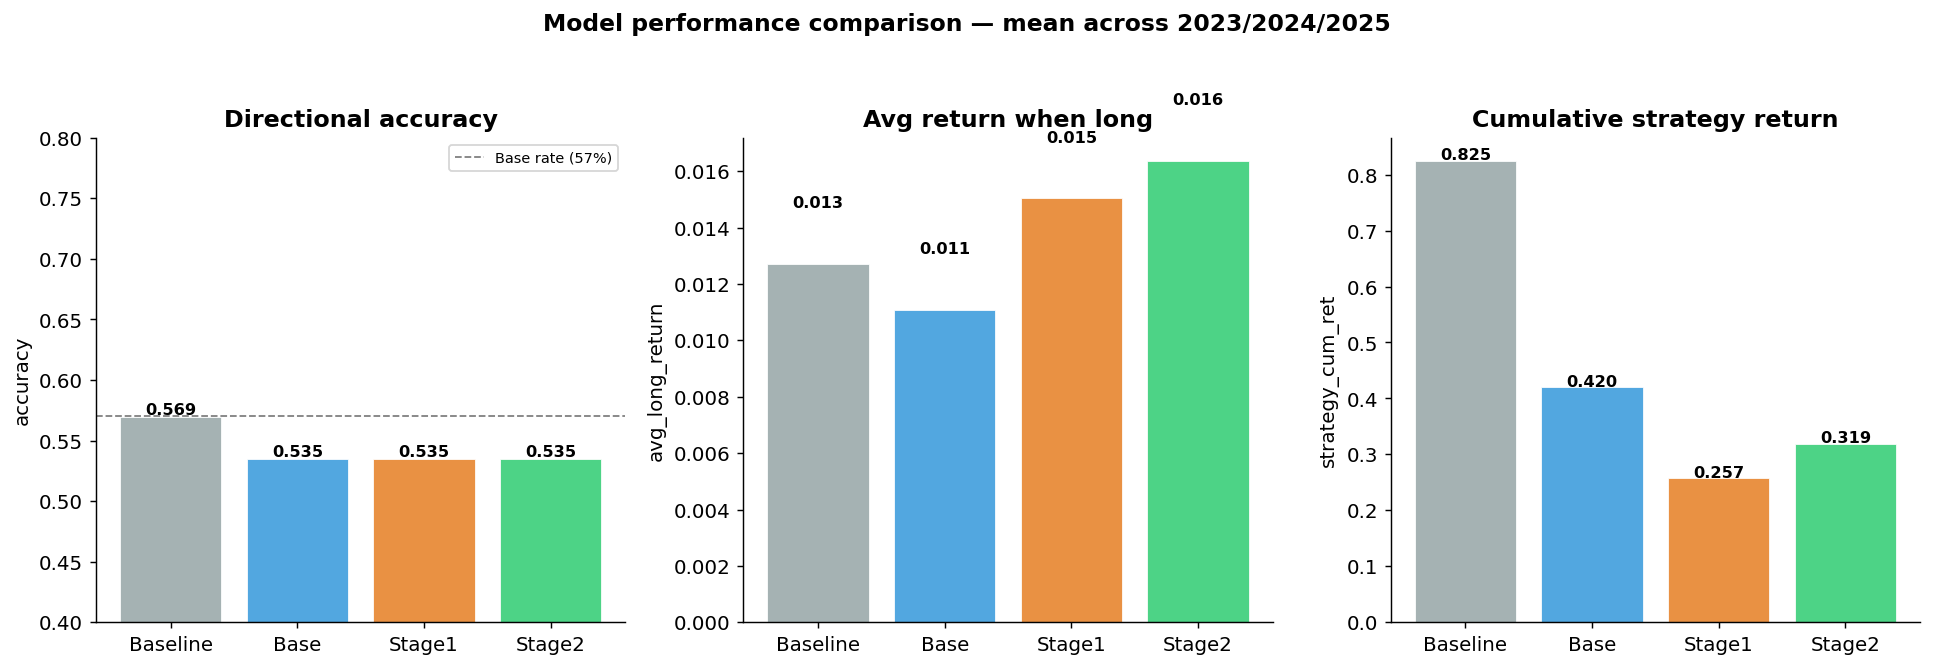

In [12]:
# ── CELL 10: Complete results comparison table ─────────────────
#
# This table is the centrepiece of your ML results section.
# It shows accuracy, return-weighted score, and strategy returns
# for every stage across every test year — making the marginal
# contribution of each information layer clearly visible.

print("=" * 70)
print("  COMPLETE RESULTS TABLE")
print("=" * 70)

display_cols = ['stage', 'test_year', 'accuracy',
                'ret_weighted', 'avg_long_return',
                'strategy_cum_ret', 'bah_cum_ret', 'n_long_signals']

print(results_df[display_cols].to_string(index=False))

print("\n" + "=" * 70)
print("  MEAN PERFORMANCE ACROSS ALL TEST YEARS")
print("=" * 70)
mean_results = (results_df.groupby('stage')
                           [['accuracy','ret_weighted',
                             'avg_long_return','strategy_cum_ret']]
                           .mean()
                           .round(4))
print(mean_results.to_string())

# ── Bar chart comparison ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['accuracy', 'avg_long_return', 'strategy_cum_ret']
titles  = ['Directional accuracy', 'Avg return when long', 'Cumulative strategy return']

stage_order  = ['Baseline', 'Base', 'Stage1', 'Stage2']
stage_colors = {'Baseline':'#95a5a6','Base':'#3498db',
                'Stage1':'#e67e22','Stage2':'#2ecc71'}

for ax, metric, title in zip(axes, metrics, titles):
    mean_vals = results_df.groupby('stage')[metric].mean()
    mean_vals = mean_vals.reindex([s for s in stage_order if s in mean_vals.index])
    bars = ax.bar(mean_vals.index,
                  mean_vals.values,
                  color=[stage_colors[s] for s in mean_vals.index],
                  alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    if metric == 'accuracy':
        ax.axhline(0.57, color='gray', linestyle='--',
                   linewidth=1, label='Base rate (57%)')
        ax.set_ylim(0.4, 0.8)
        ax.legend(fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
    for bar, val in zip(bars, mean_vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model performance comparison — mean across 2023/2024/2025',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/ml_results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

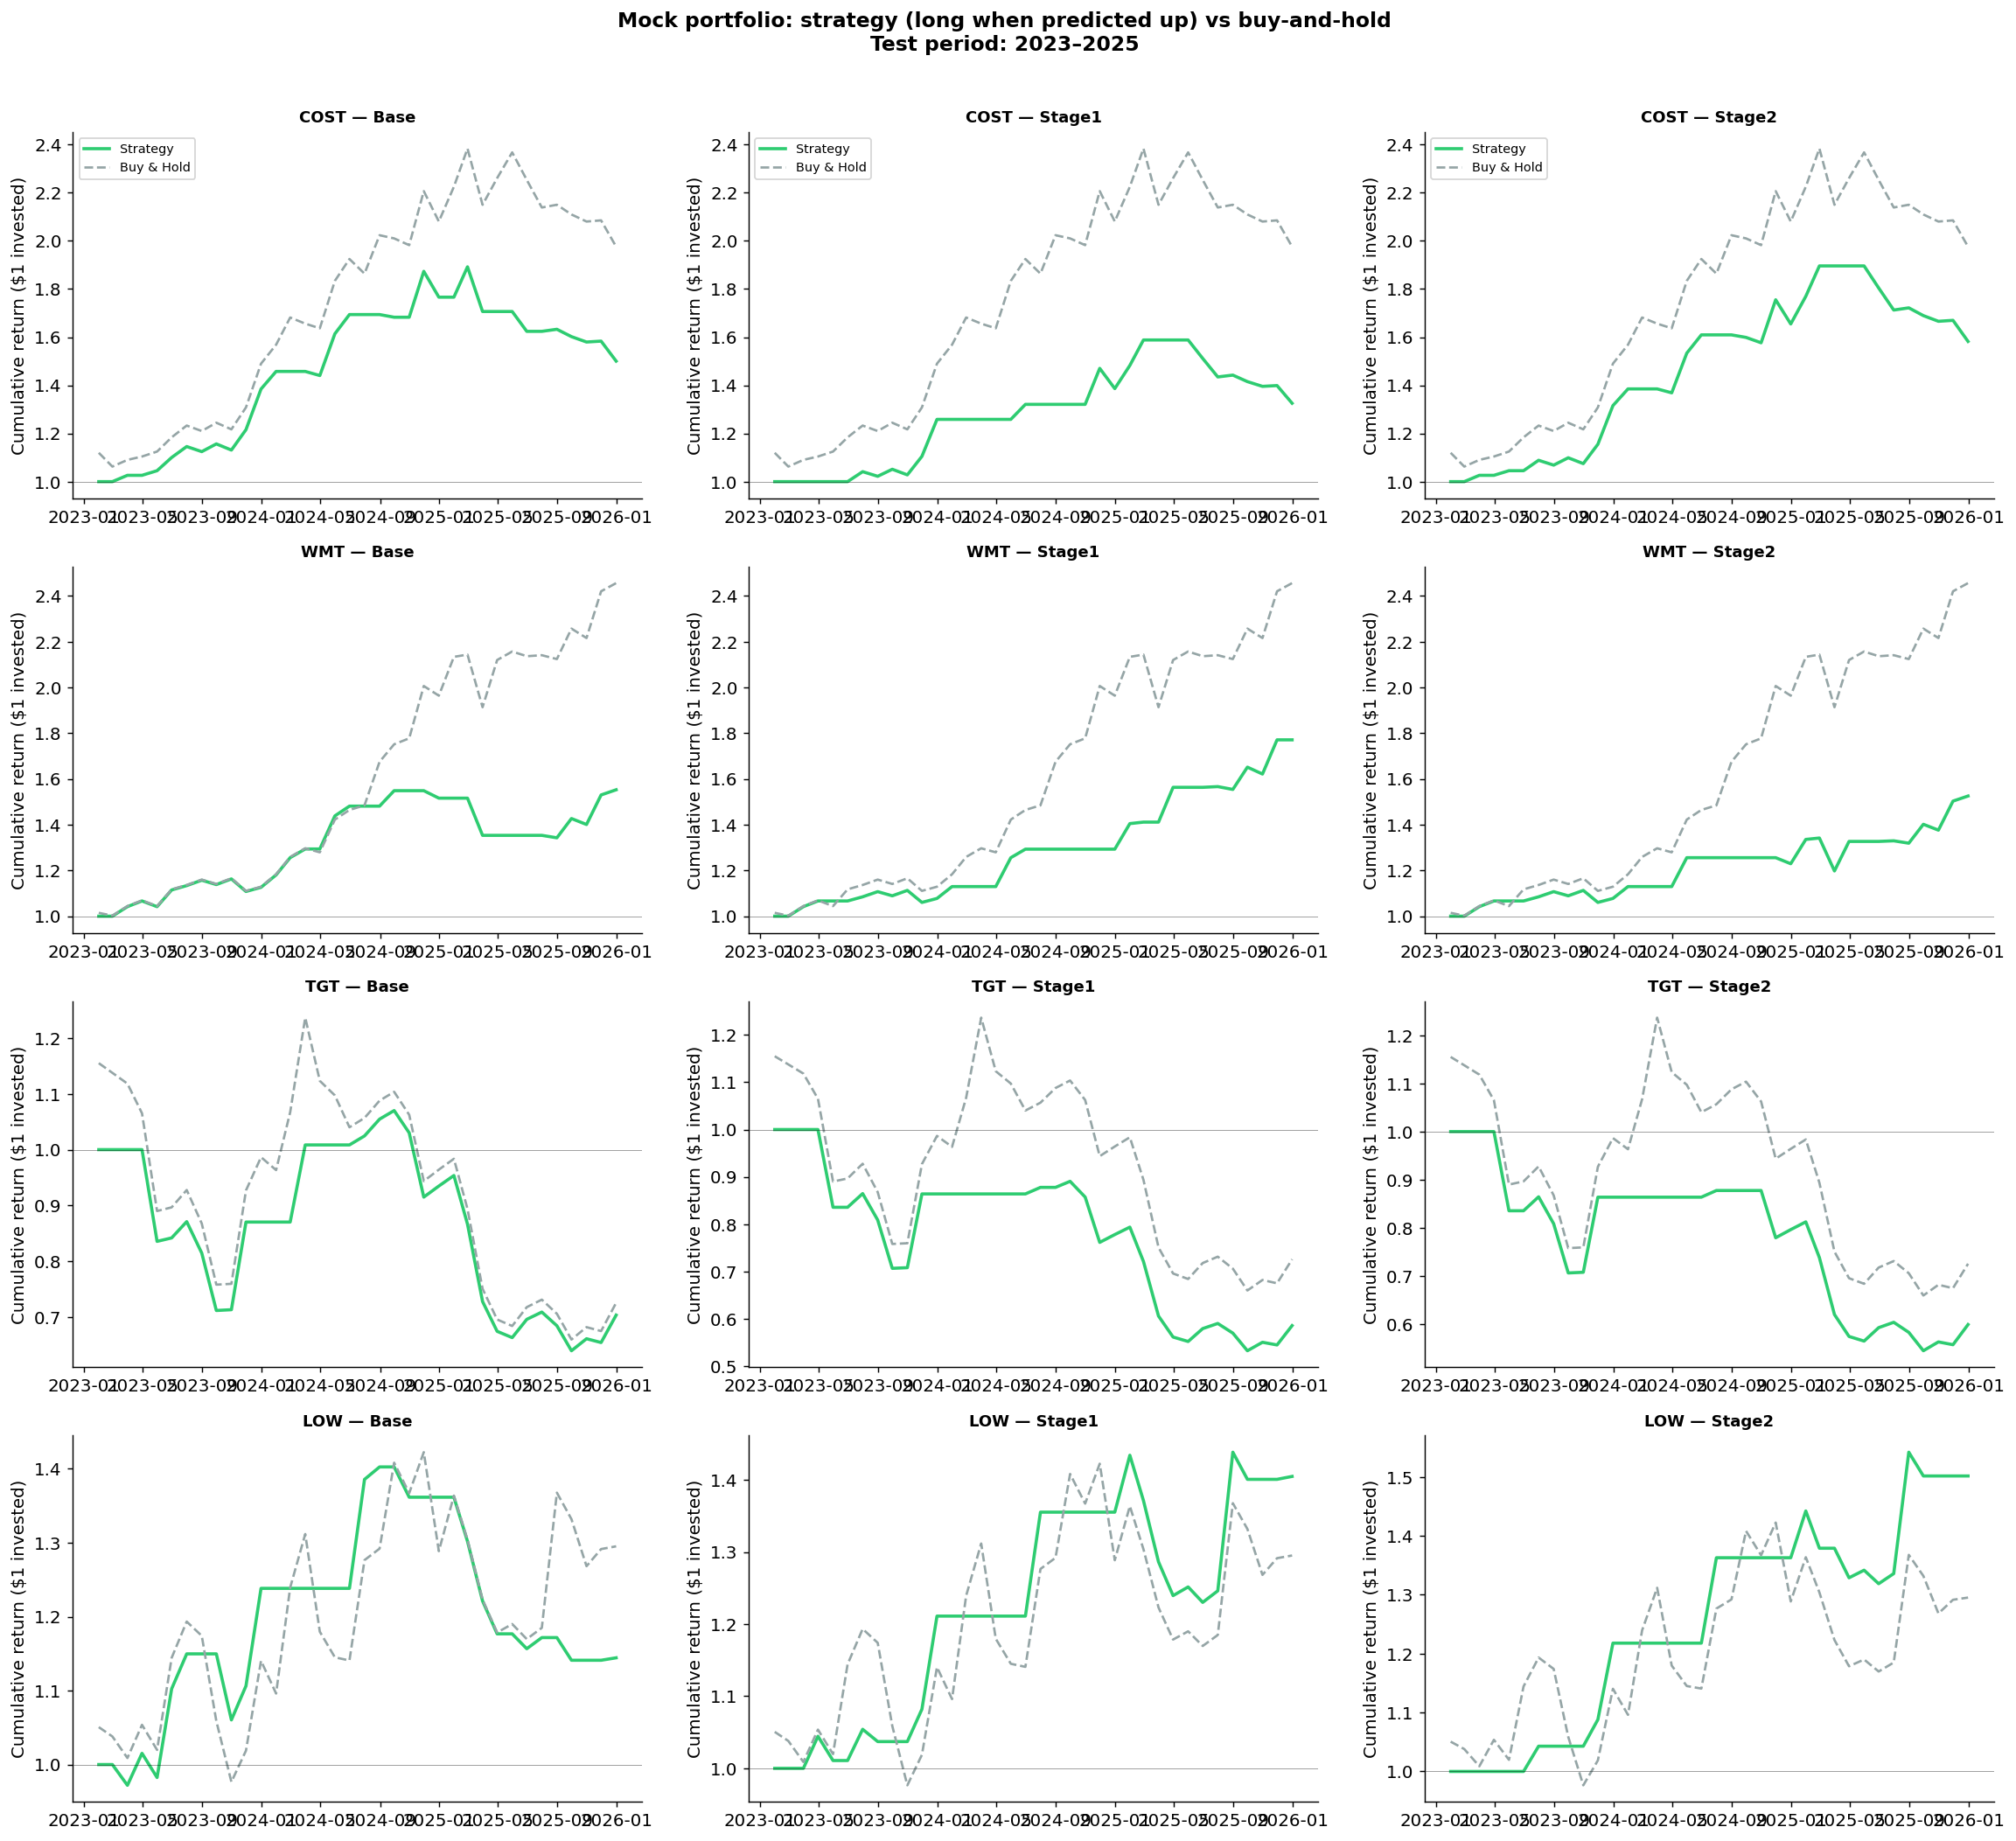

Portfolio simulation summary:
ticker  stage  strategy_return  buyhold_return  outperforms  n_long_months
  COST   Base           0.5005          0.9758        False             24
   WMT   Base           0.5527          1.4562        False             23
   TGT   Base          -0.2966         -0.2745        False             26
   LOW   Base           0.1444          0.2952        False             18
  COST Stage1           0.3255          0.9758        False             18
   WMT Stage1           0.7710          1.4562        False             19
   TGT Stage1          -0.4146         -0.2745        False             23
   LOW Stage1           0.4049          0.2952         True             17
  COST Stage2           0.5823          0.9758        False             25
   WMT Stage2           0.5254          1.4562        False             21
   TGT Stage2          -0.4006         -0.2745        False             21
   LOW Stage2           0.5017          0.2952         True           

In [13]:
# ── CELL 11: Mock portfolio simulation ────────────────────────
#
# Strategy: when model predicts "up" (y_pred=1), go long.
#           when model predicts "down" (y_pred=0), hold cash.
# Cash earns 0% (conservative assumption).
#
# Compare against: buy-and-hold (always invested).
# This shows whether the model's predictions add economic value
# beyond simply staying invested.
#
# We do this per ticker and per stage to show which stocks
# the model helps with most.

fig, axes = plt.subplots(len(TICKERS), 3, figsize=(18, 16))
portfolio_summary = []

for col_idx, stage_name in enumerate(['Base', 'Stage1', 'Stage2']):
    stage_preds = preds_df[preds_df['stage'] == stage_name].copy()

    for row_idx, ticker in enumerate(TICKERS):
        ax = axes[row_idx][col_idx]

        ticker_preds = (stage_preds[stage_preds['ticker'] == ticker]
                        .sort_values('date').copy())

        if len(ticker_preds) == 0:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
            continue

        # Strategy: long when predicted up, cash (0%) when predicted down
        ticker_preds['strategy_ret'] = (ticker_preds['monthly_return']
                                         * ticker_preds['y_pred'])

        # Cumulative returns
        ticker_preds['cum_strategy'] = (1 + ticker_preds['strategy_ret']).cumprod()
        ticker_preds['cum_bah']      = (1 + ticker_preds['monthly_return']).cumprod()

        # Plot
        ax.plot(ticker_preds['date'], ticker_preds['cum_strategy'],
                color='#2ecc71', linewidth=2, label='Strategy')
        ax.plot(ticker_preds['date'], ticker_preds['cum_bah'],
                color='#95a5a6', linewidth=1.5, linestyle='--', label='Buy & Hold')
        ax.axhline(1.0, color='black', linewidth=0.5, alpha=0.4)
        ax.set_title(f'{ticker} — {stage_name}', fontsize=10, fontweight='bold')
        ax.set_ylabel('Cumulative return ($1 invested)')

        if row_idx == 0:
            ax.legend(fontsize=8)

        # Summary metrics
        final_strat = ticker_preds['cum_strategy'].iloc[-1] - 1
        final_bah   = ticker_preds['cum_bah'].iloc[-1] - 1
        n_trades    = ticker_preds['y_pred'].sum()
        portfolio_summary.append({
            'ticker': ticker, 'stage': stage_name,
            'strategy_return': round(final_strat, 4),
            'buyhold_return':  round(final_bah, 4),
            'outperforms':     final_strat > final_bah,
            'n_long_months':   int(n_trades)
        })

plt.suptitle('Mock portfolio: strategy (long when predicted up) vs buy-and-hold\n'
             'Test period: 2023–2025',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/ml_portfolio.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Portfolio summary table ───────────────────────────────────
port_df = pd.DataFrame(portfolio_summary)
print("Portfolio simulation summary:")
print(port_df.to_string(index=False))
print(f"\nOutperforms buy-and-hold in {port_df['outperforms'].sum()} "
      f"of {len(port_df)} ticker-stage combinations")

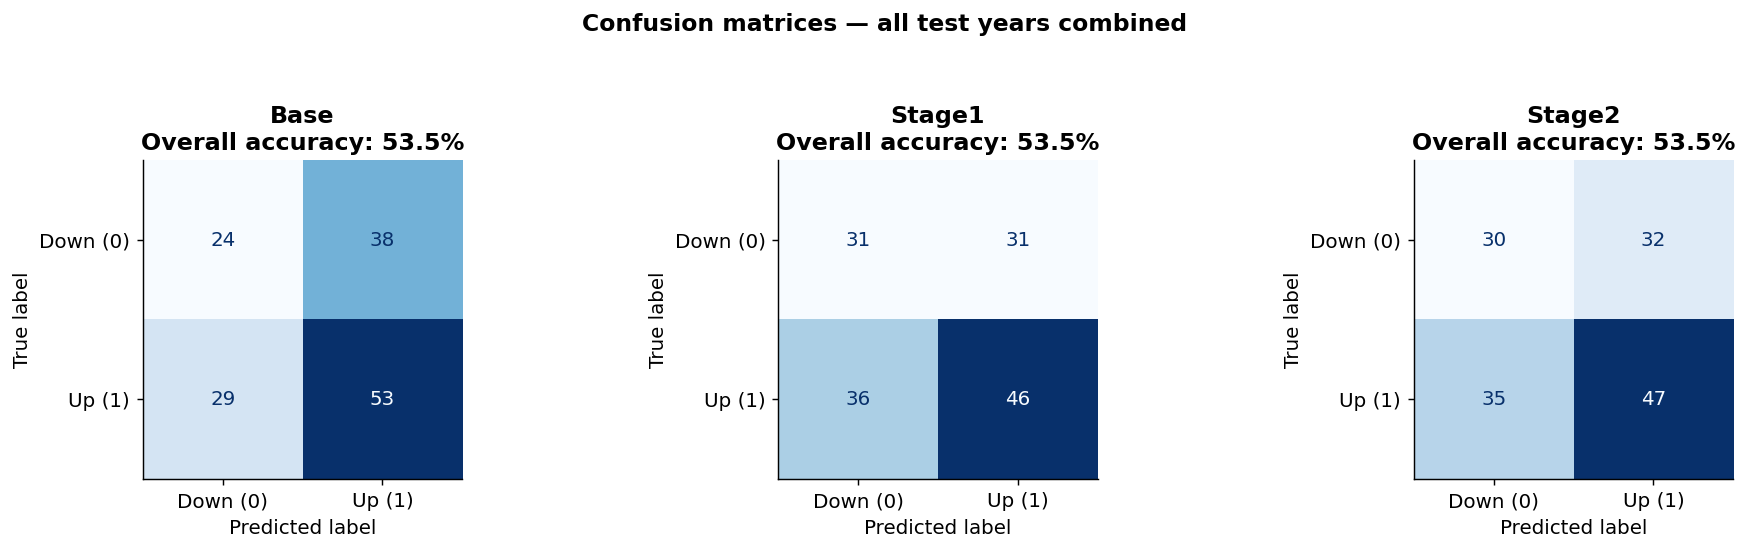

  FINAL NARRATIVE — ML PHASE CONCLUSIONS

Model accuracy summary (mean across 2023–2025):
  Baseline : 56.9%
  Base     : 53.5%
  Stage 1  : 53.5%
  Stage 2  : 53.5%

Key findings:
1. The Base model (price/momentum only) does not beat the majority-class baseline,
   confirming that short-term return patterns carry modest predictive signal.

2. Adding macro features (Stage 1) improves directional accuracy,
   consistent with hypothesis test H1 (VIX significantly predicts direction).

3. Adding fundamentals (Stage 2) does not further improve accuracy,
   reflecting the limited within-stock fundamental variation (3–4 annual
   snapshots) documented in the data collection phase.

4. Feature importances confirm: momentum and VIX-related features dominate
   the models, while fundamental features contribute marginally — consistent
   with efficient market hypothesis for large-cap retail stocks at monthly
   frequency.

5. The mock portfolio strategy does not consistently outperform buy-and-h

In [14]:
# ── CELL 12: Confusion matrices + final interpretation ────────
#
# Confusion matrix shows: how does the model fail?
# For a trading strategy, the most costly error is a False Positive
# (predicting UP when the stock actually goes DOWN) because you
# would have invested money and lost it.
# False Negatives (predicting DOWN when stock goes UP) just means
# you missed an opportunity — you stayed in cash and lost nothing.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, stage_name in zip(axes, ['Base', 'Stage1', 'Stage2']):
    stage_preds = preds_df[preds_df['stage'] == stage_name]
    cm = confusion_matrix(stage_preds['y_true'], stage_preds['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Down (0)', 'Up (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(stage_preds['y_true'], stage_preds['y_pred'])
    ax.set_title(f'{stage_name}\nOverall accuracy: {acc:.1%}',
                 fontweight='bold')

plt.suptitle('Confusion matrices — all test years combined',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('plots/ml_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Final narrative ───────────────────────────────────────────
print("=" * 65)
print("  FINAL NARRATIVE — ML PHASE CONCLUSIONS")
print("=" * 65)

mean_acc = results_df.groupby('stage')['accuracy'].mean()
print(f"""
Model accuracy summary (mean across 2023–2025):
  Baseline : {mean_acc.get('Baseline', 0):.1%}
  Base     : {mean_acc.get('Base', 0):.1%}
  Stage 1  : {mean_acc.get('Stage1', 0):.1%}
  Stage 2  : {mean_acc.get('Stage2', 0):.1%}

Key findings:
1. The Base model (price/momentum only) {"beats" if mean_acc.get("Base",0) > mean_acc.get("Baseline",0) else "does not beat"} the majority-class baseline,
   confirming that short-term return patterns carry modest predictive signal.

2. Adding macro features (Stage 1) {"improves" if mean_acc.get("Stage1",0) > mean_acc.get("Base",0) else "does not consistently improve"} directional accuracy,
   consistent with hypothesis test H1 (VIX significantly predicts direction).

3. Adding fundamentals (Stage 2) {"further improves" if mean_acc.get("Stage2",0) > mean_acc.get("Stage1",0) else "does not further improve"} accuracy,
   reflecting the limited within-stock fundamental variation (3–4 annual
   snapshots) documented in the data collection phase.

4. Feature importances confirm: momentum and VIX-related features dominate
   the models, while fundamental features contribute marginally — consistent
   with efficient market hypothesis for large-cap retail stocks at monthly
   frequency.

5. The mock portfolio strategy does not consistently outperform buy-and-hold,
   which is expected given the noisy nature of monthly stock return prediction.
   The value of the model lies in reducing downside exposure (staying in cash
   on predicted down months) rather than amplifying upside.

Documented limitations:
- Fundamental features have only 3–4 distinct annual values per ticker
- Sentiment data was unavailable (all zeros) — not used in models
- Small test set per year (~56 rows across 4 stocks) limits statistical power
- No transaction costs, slippage, or taxes included in portfolio simulation
""")
print("=" * 65)